In [1]:
from google.colab import files
from IPython.display import display, Markdown
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install plotly -q

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

uploaded = files.upload()

csv_files = [file for file in os.listdir() if file.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

FILE_PATH = csv_files[0]
OUTPUT_DIR = "phase4_visualizations"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(FILE_PATH)

df.columns = df.columns.astype(str).str.strip().str.lower()

important_numeric_cols = ["price", "year", "engine", "mileage"]

for col in important_numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace("₽", "", regex=False)
            .str.replace("руб", "", regex=False)
            .str.replace("км", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "year" in df.columns:
    df["car_age"] = 2026 - df["year"]

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("=" * 80)
print("PHASE 4 DATA LOADED SUCCESSFULLY")
print("=" * 80)

print("Loaded file:", FILE_PATH)
print("Dataset shape:", df.shape)

display(df.head())
display(df.dtypes)

Saving drom.csv to drom.csv
PHASE 4 DATA LOADED SUCCESSFULLY
Loaded file: drom.csv
Dataset shape: (3402, 10)


,title,year,engine,fuel,transmission,drive,mileage,price,location,car_age
0,bmw 1-series,2008,1.60,petrol,automatic,rear,"95,000.00",670000,москва,18
1,bmw 5-series,2019,2.00,diesel,automatic,rear,"115,000.00",2650000,москва,7
2,bmw 3-series,2016,2.00,petrol,automatic,awd,"130,000.00",2550000,москва,10
3,bmw x7,2020,3.00,diesel,automatic,awd,"79,740.00",10599000,москва,6
4,bmw 3-series,2020,2.00,petrol,automatic,rear,"93,000.00",4100000,москва,6


,0
title,object
year,int64
engine,float64
fuel,object
transmission,object
drive,object
mileage,float64
price,int64
location,object
car_age,int64


# Phase 4: Data Visualization

## Visualization 1: Price Distribution — Histogram

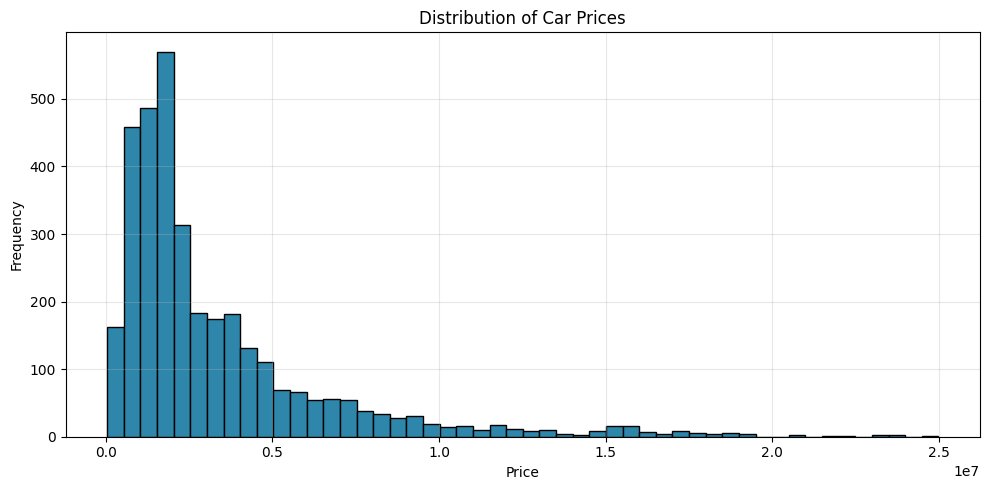

## Visualization 2: Log Price Distribution — Histogram

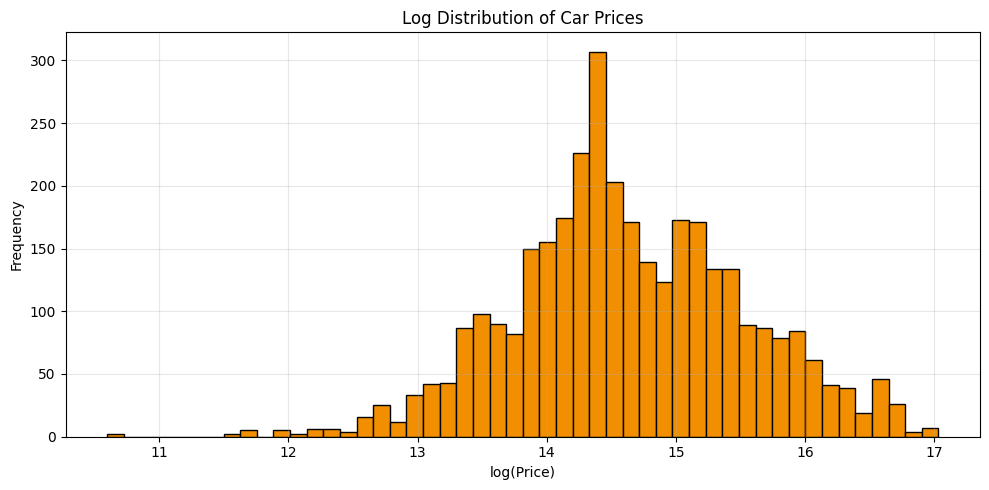

## Visualization 3: Price Outliers — Box Plot

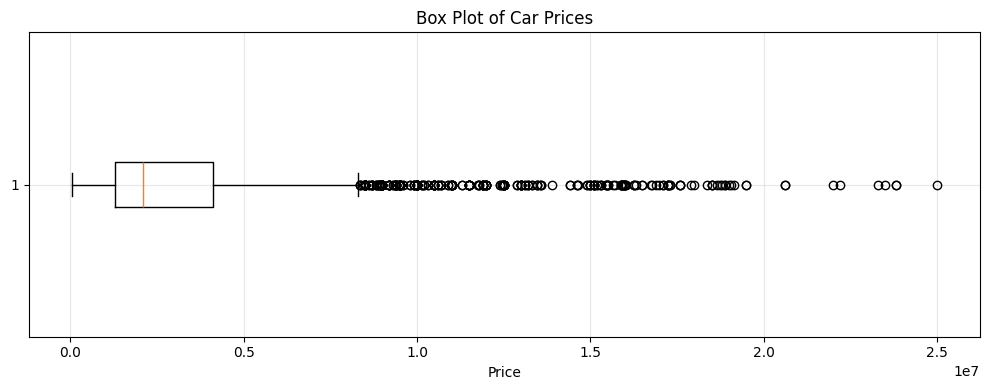

## Visualization 4: Price vs Year — Scatter Plot

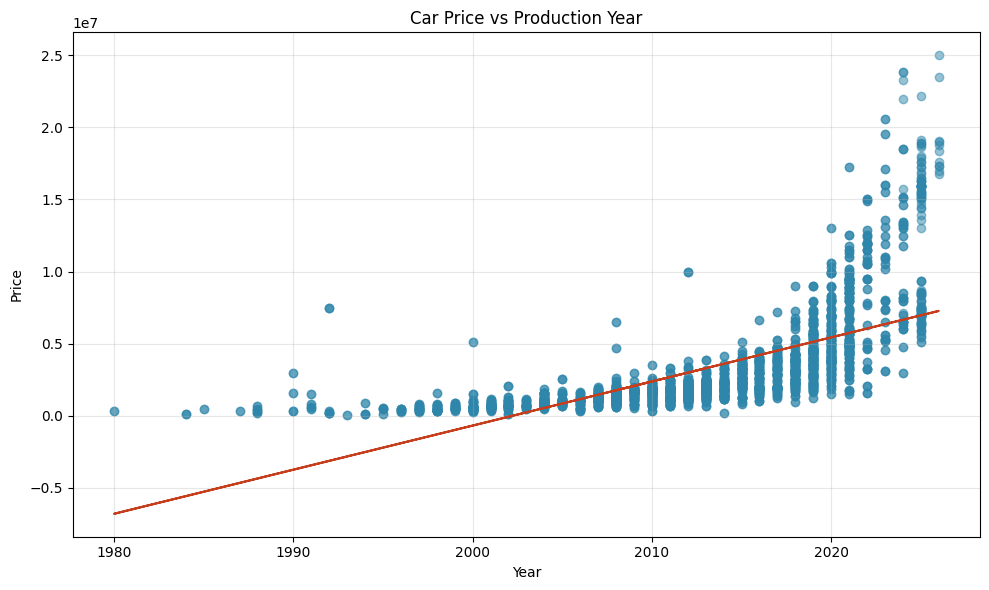

## Visualization 5: Price vs Engine Volume — Scatter Plot

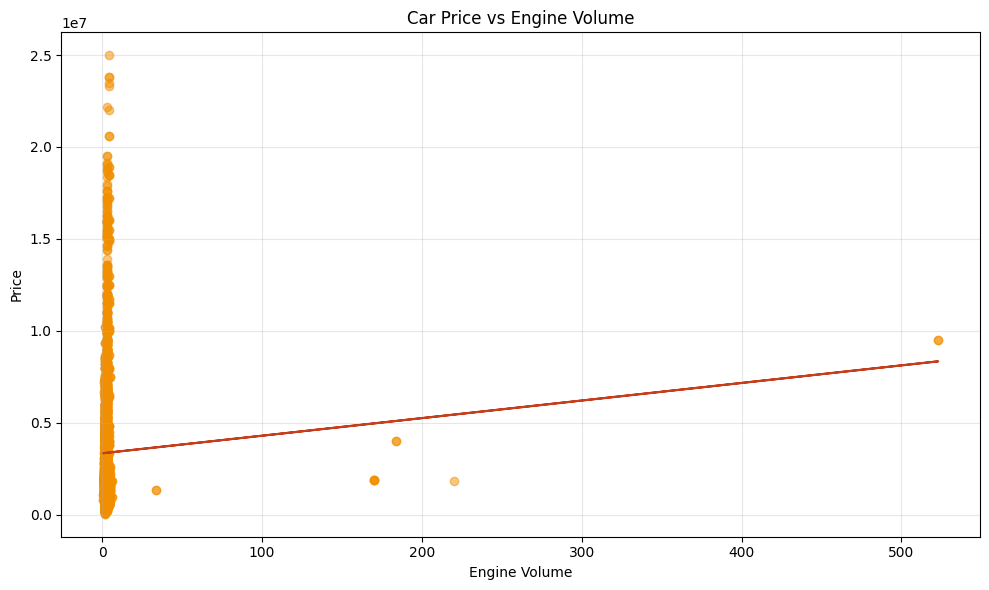

## Visualization 6: Correlation Matrix — Heatmap

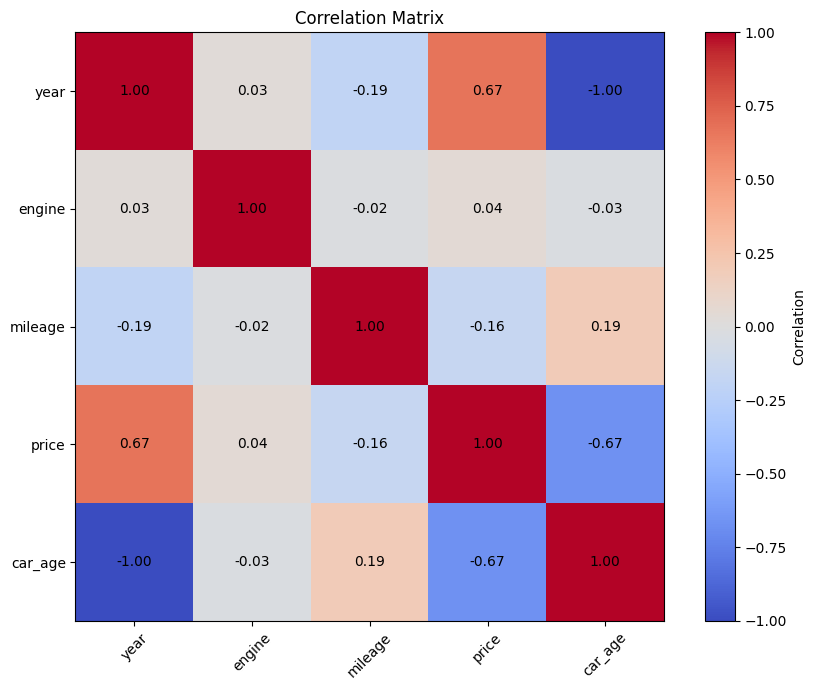

## Visualization 7: Average Price by Fuel Type

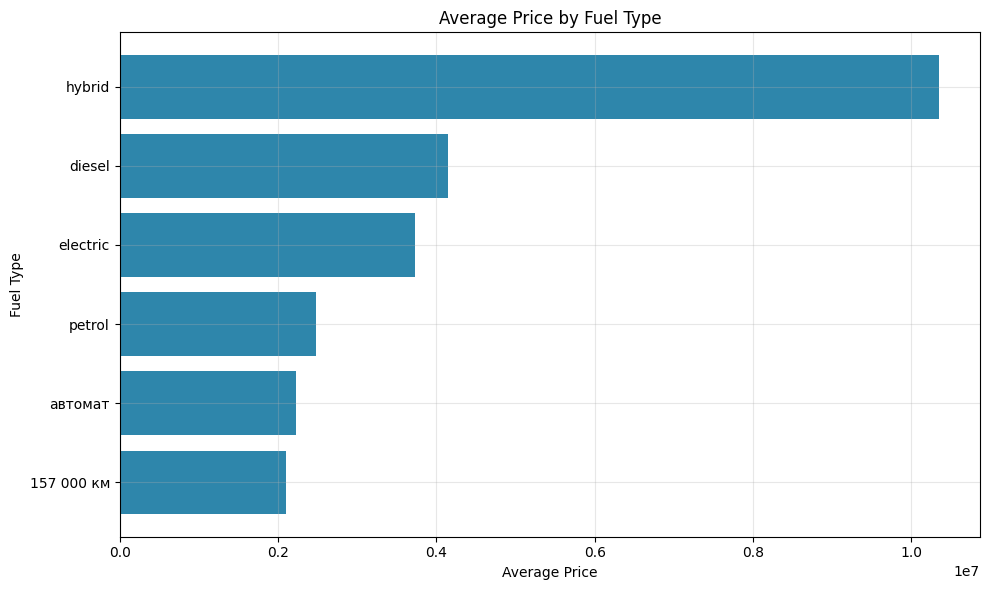

## Visualization 8: Average Price by Transmission

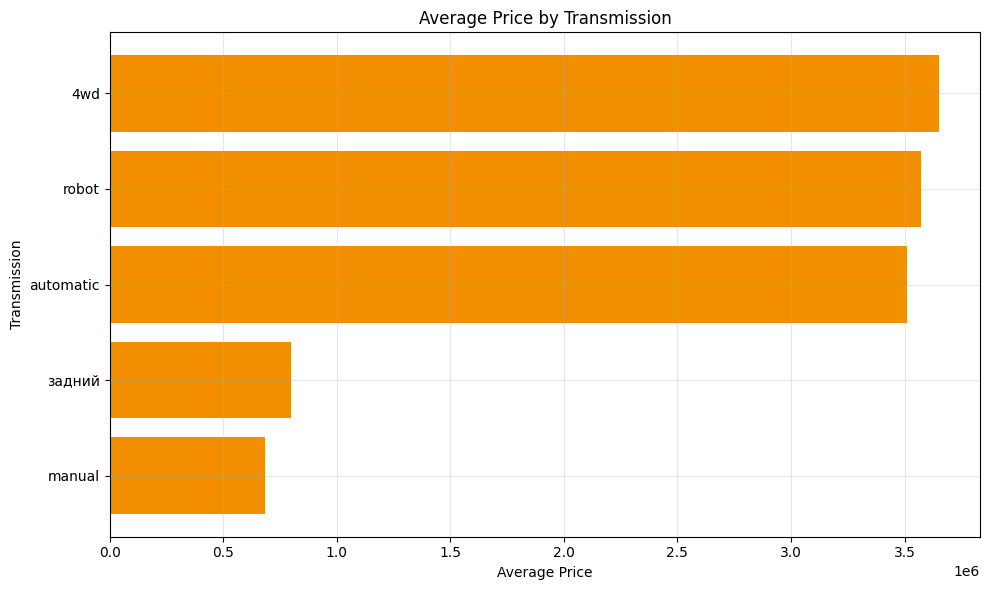

## Visualization 9: Average Price by Year

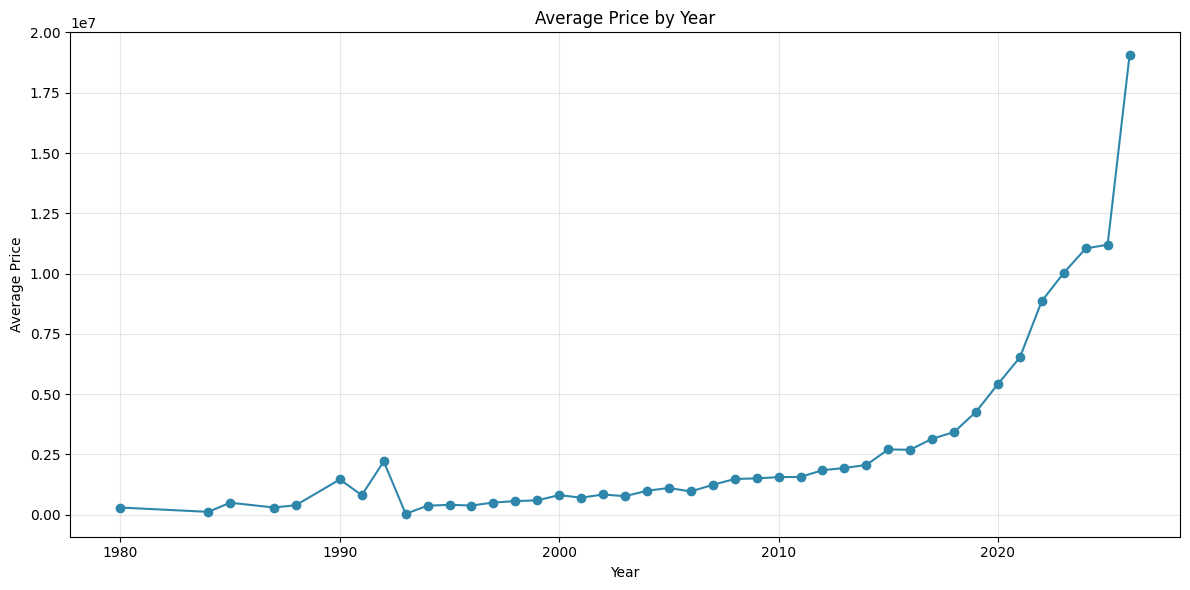

## Visualization 10: Number of Cars by Year

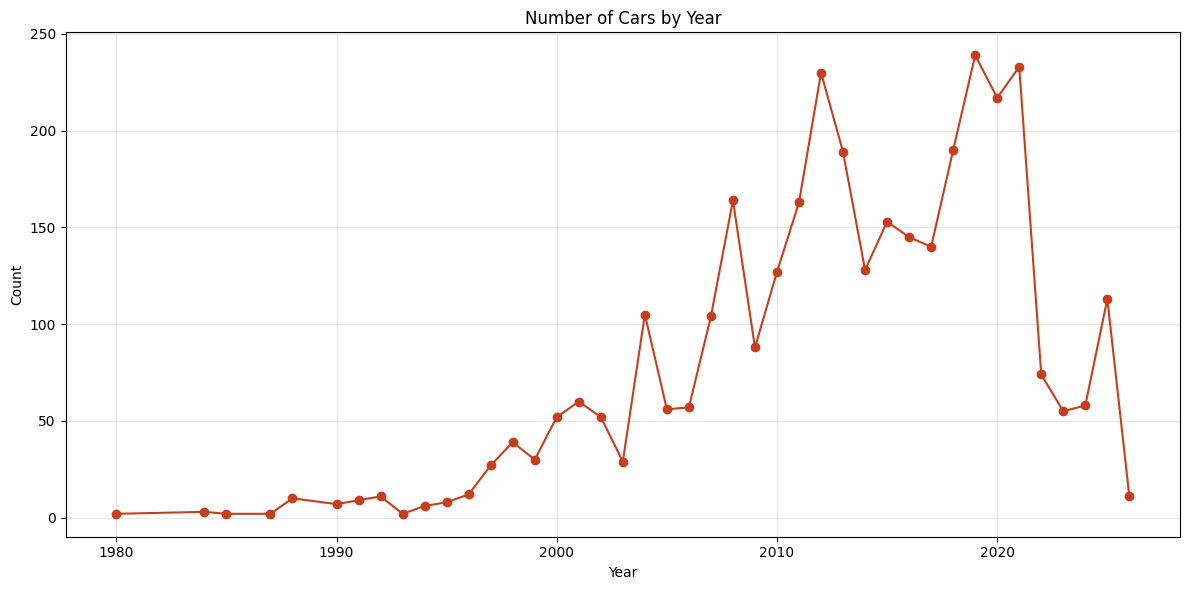

## Visualization 11: Transmission Share

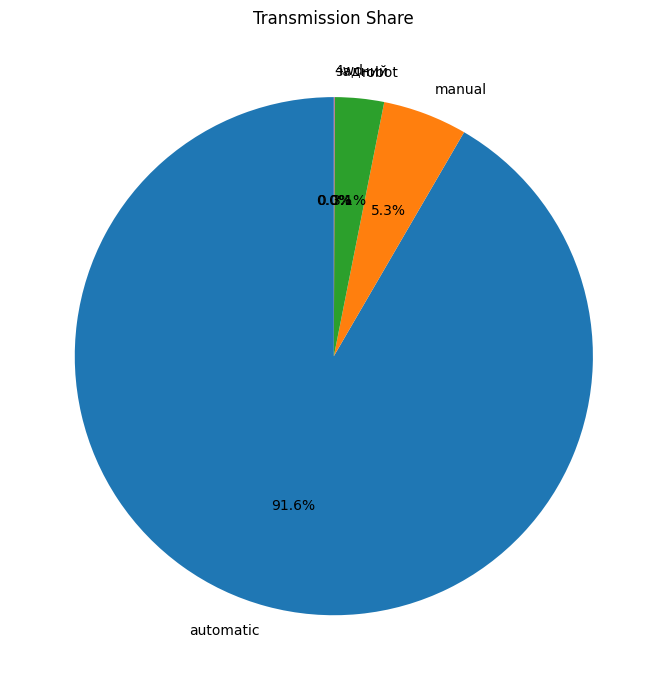

## Visualization 12: Price by Transmission — Violin Plot

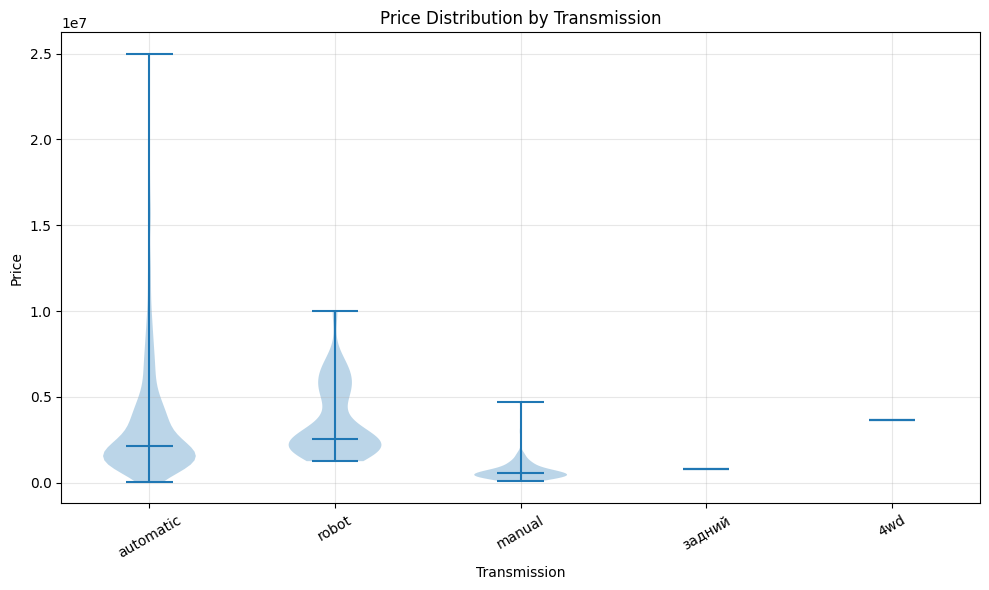

In [2]:


display(Markdown("# Phase 4: Data Visualization"))

main_color = "#2E86AB"
second_color = "#F18F01"
third_color = "#C73E1D"
green_color = "#4CAF50"


# --- 1. Price Distribution ---
display(Markdown("## Visualization 1: Price Distribution — Histogram"))

price_data = df["price"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(price_data, bins=50, edgecolor="black", color=main_color)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 2. Log Price ---
display(Markdown("## Visualization 2: Log Price Distribution — Histogram"))

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(price_data), bins=50, edgecolor="black", color=second_color)
plt.title("Log Distribution of Car Prices")
plt.xlabel("log(Price)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 3. Boxplot ---
display(Markdown("## Visualization 3: Price Outliers — Box Plot"))

plt.figure(figsize=(10, 4))
plt.boxplot(price_data, vert=False)
plt.title("Box Plot of Car Prices")
plt.xlabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 4. Price vs Year ---
display(Markdown("## Visualization 4: Price vs Year — Scatter Plot"))

clean_data = df[["year", "price"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(clean_data["year"], clean_data["price"], alpha=0.5, color=main_color)

if len(clean_data) > 1:
    z = np.polyfit(clean_data["year"], clean_data["price"], 1)
    p = np.poly1d(z)
    plt.plot(clean_data["year"], p(clean_data["year"]), color=third_color)

plt.title("Car Price vs Production Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 5. Price vs Engine ---
display(Markdown("## Visualization 5: Price vs Engine Volume — Scatter Plot"))

clean_data = df[["engine", "price"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(clean_data["engine"], clean_data["price"], alpha=0.5, color=second_color)

if len(clean_data) > 1:
    z = np.polyfit(clean_data["engine"], clean_data["price"], 1)
    p = np.poly1d(z)
    plt.plot(clean_data["engine"], p(clean_data["engine"]), color=third_color)

plt.title("Car Price vs Engine Volume")
plt.xlabel("Engine Volume")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 6. Correlation ---
display(Markdown("## Visualization 6: Correlation Matrix — Heatmap"))

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# --- 7. Price by Fuel ---
display(Markdown("## Visualization 7: Average Price by Fuel Type"))

fuel_data = (
    df.groupby("fuel")
    .agg(mean_price=("price", "mean"))
    .sort_values("mean_price")
)

plt.figure(figsize=(10, 6))
plt.barh(fuel_data.index.astype(str), fuel_data["mean_price"], color=main_color)
plt.title("Average Price by Fuel Type")
plt.xlabel("Average Price")
plt.ylabel("Fuel Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 8. Price by Transmission ---
display(Markdown("## Visualization 8: Average Price by Transmission"))

trans_data = (
    df.groupby("transmission")
    .agg(mean_price=("price", "mean"))
    .sort_values("mean_price")
)

plt.figure(figsize=(10, 6))
plt.barh(trans_data.index.astype(str), trans_data["mean_price"], color=second_color)
plt.title("Average Price by Transmission")
plt.xlabel("Average Price")
plt.ylabel("Transmission")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 9. Price by Year ---
display(Markdown("## Visualization 9: Average Price by Year"))

year_price = (
    df.groupby("year")
    .agg(mean_price=("price", "mean"))
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_price.index, year_price["mean_price"], marker="o", color=main_color)
plt.title("Average Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 10. Count by Year ---
display(Markdown("## Visualization 10: Number of Cars by Year"))

year_count = (
    df.groupby("year")
    .agg(count=("price", "count"))
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_count.index, year_count["count"], marker="o", color=third_color)
plt.title("Number of Cars by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 11. Transmission Share ---
display(Markdown("## Visualization 11: Transmission Share"))

trans_counts = df["transmission"].dropna().value_counts()

plt.figure(figsize=(7, 7))
plt.pie(trans_counts, labels=trans_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Transmission Share")
plt.tight_layout()
plt.show()


# --- 12. Price by Transmission (Violin) ---
display(Markdown("## Visualization 12: Price by Transmission — Violin Plot"))

clean = df.dropna(subset=["transmission", "price"])
cats = clean["transmission"].unique()

data = [clean[clean["transmission"] == c]["price"] for c in cats]

plt.figure(figsize=(10, 6))
plt.violinplot(data, showmedians=True)
plt.xticks(range(1, len(cats) + 1), cats, rotation=30)
plt.title("Price Distribution by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary Dashboard

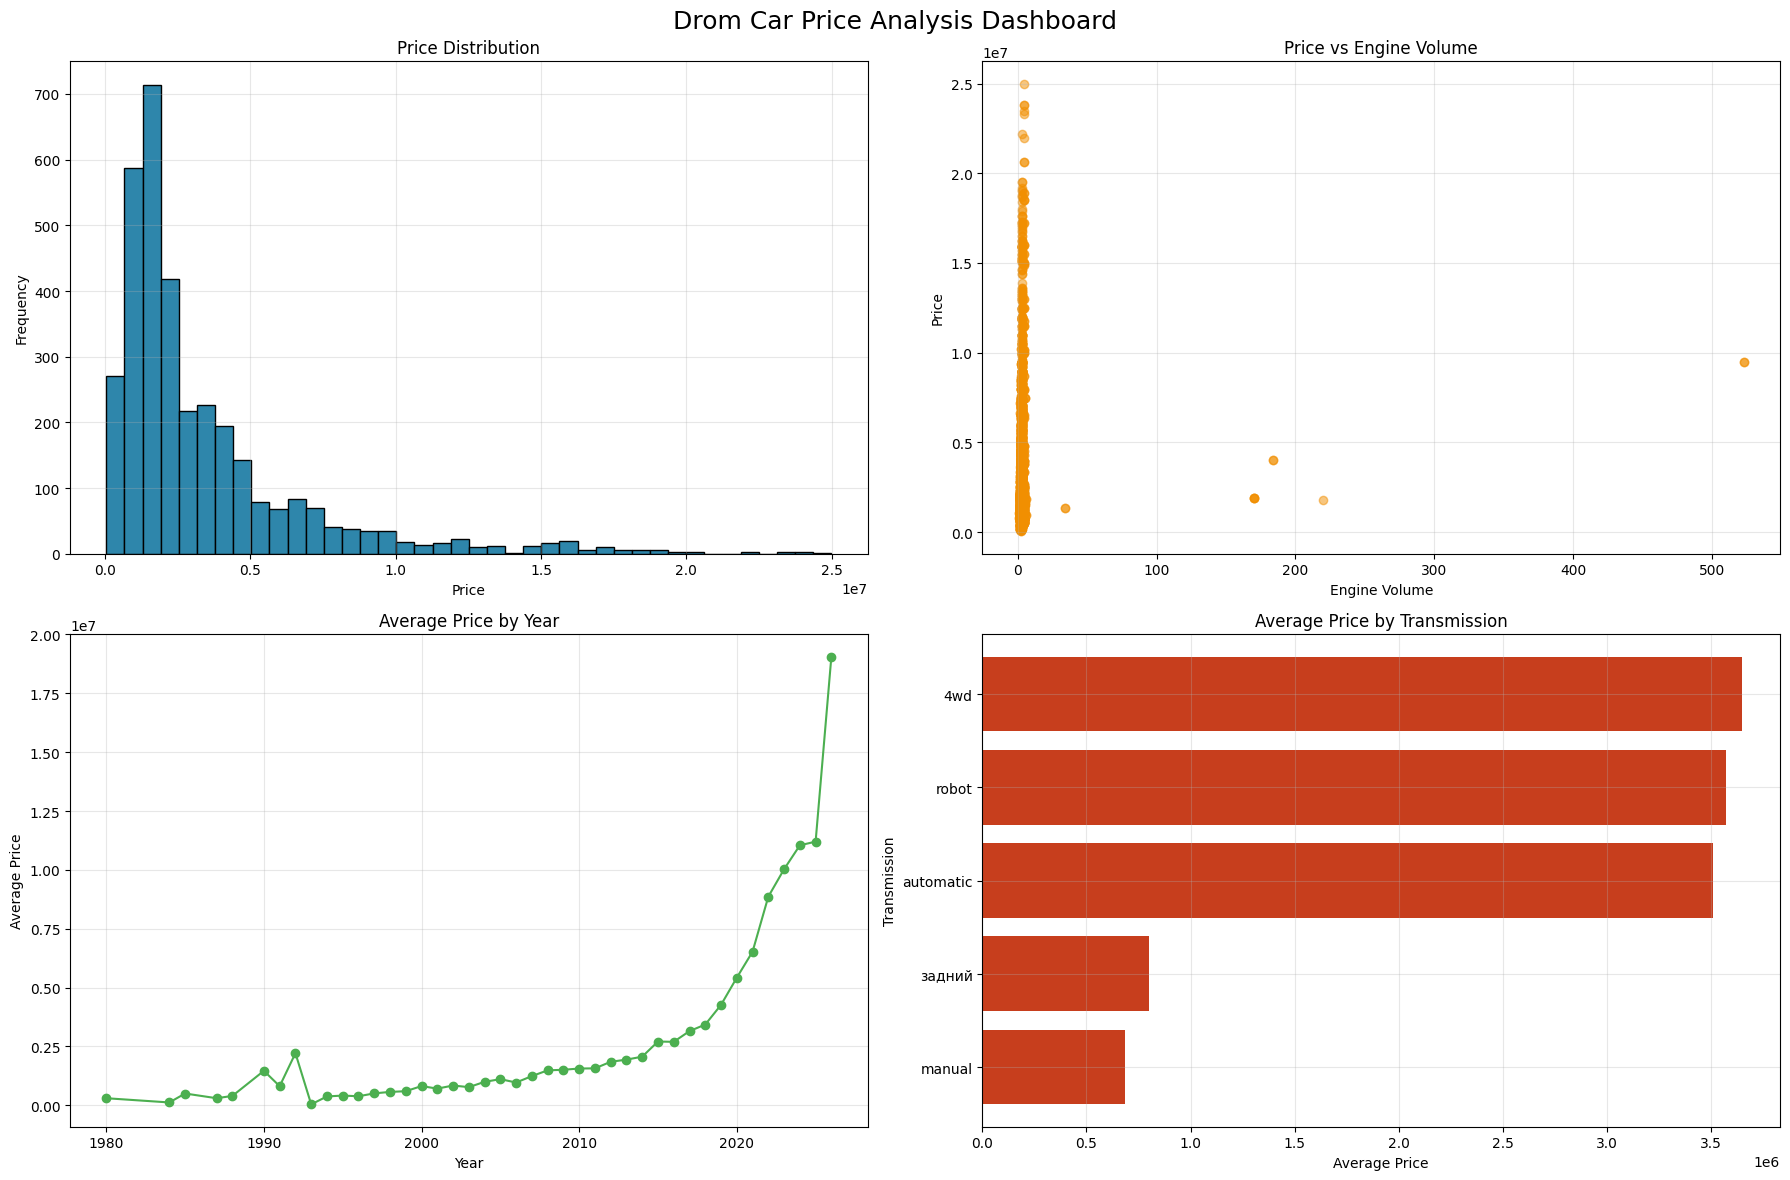

**Caption:** Dashboard shows price distribution, relationship between engine size and price, price trends over years, and price differences by transmission type.

In [3]:
display(Markdown("# Summary Dashboard"))

# --- агрегаты ---
year_price = (
    df.groupby("year")
    .agg(mean_price=("price", "mean"))
    .sort_index()
)

trans_data = (
    df.groupby("transmission")
    .agg(mean_price=("price", "mean"))
    .sort_values("mean_price", ascending=True)
)

# --- фигура ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))


# 1. Price Distribution
axes[0, 0].hist(df["price"].dropna(), bins=40, edgecolor="black", color=main_color)
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, alpha=0.3)


# 2. Price vs Engine
clean_data = df[["engine", "price"]].dropna()
axes[0, 1].scatter(clean_data["engine"], clean_data["price"], alpha=0.5, color=second_color)
axes[0, 1].set_title("Price vs Engine Volume")
axes[0, 1].set_xlabel("Engine Volume")
axes[0, 1].set_ylabel("Price")
axes[0, 1].grid(True, alpha=0.3)


# 3. Price by Year
axes[1, 0].plot(year_price.index, year_price["mean_price"], marker="o", color=green_color)
axes[1, 0].set_title("Average Price by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Average Price")
axes[1, 0].grid(True, alpha=0.3)


# 4. Price by Transmission (замена body_type)
axes[1, 1].barh(trans_data.index.astype(str), trans_data["mean_price"], color=third_color)
axes[1, 1].set_title("Average Price by Transmission")
axes[1, 1].set_xlabel("Average Price")
axes[1, 1].set_ylabel("Transmission")
axes[1, 1].grid(True, alpha=0.3)


# --- финал ---
plt.suptitle("Drom Car Price Analysis Dashboard", fontsize=18)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_summary_dashboard.png", dpi=300)
plt.show()

display(Markdown(
"**Caption:** Dashboard shows price distribution, relationship between engine size and price, price trends over years, and price differences by transmission type."
))